<a href="https://colab.research.google.com/github/AthienaRae/ImageProcessingAndComputerVision_06/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# Download YOLO files if they don't exist
if not os.path.exists('yolov3.cfg'):
    !wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
if not os.path.exists('yolov3.weights'):
    !wget https://pjreddie.com/media/files/yolov3.weights
if not os.path.exists('coco.names'):
    !wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2026-05-14 17:30:47--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0s      

2026-05-14 17:30:47 (88.8 MB/s) - ‘yolov3.cfg’ saved [8342/8342]

--2026-05-14 17:30:47--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-05-14 17:30:48--  https://data.pjred

Original Image:


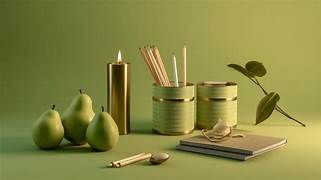


Image with Detections:


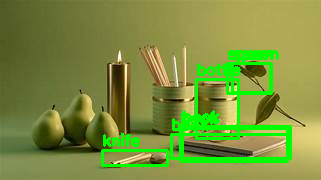

Detection complete. Output saved to yolo_detection_output.jpeg


In [5]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("object.jpeg")

# Display the original image
print("Original Image:")
cv2_imshow(img)

net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

classes = open("coco.names").read().strip().split("\n")

model = cv2.dnn_DetectionModel(net)
model.setInputParams(size=(320,320), scale=1/255)

# Lowering the confidence threshold to try and detect more objects
cls, conf, box = model.detect(img, confThreshold=0.2)

for c, s, b in zip(cls, conf, box):
    cv2.rectangle(img, b, (0,255,0), 2)
    cv2.putText(img, classes[c], (b[0], b[1]-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

# Display the output image in the notebook
print("\nImage with Detections:")
cv2_imshow(img)

cv2.imwrite("yolo_detection_output.jpeg", img)
print("Detection complete. Output saved to yolo_detection_output.jpeg")